In [20]:
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

from scipy.optimize import curve_fit

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
np.random.seed(42)

In [21]:
x = np.arange(1, 1001, 1)
x[::100]

array([  1, 101, 201, 301, 401, 501, 601, 701, 801, 901])

In [22]:
y = np.cos(x * np.pi / 180)  + np.random.rand(len(x))
y[::100]

array([ 1.57184357,  0.44056633, -0.0836211 ,  0.59565348,  0.87799336,
       -0.17784667, -0.28617801,  1.19549147,  0.28028049, -0.99380065])

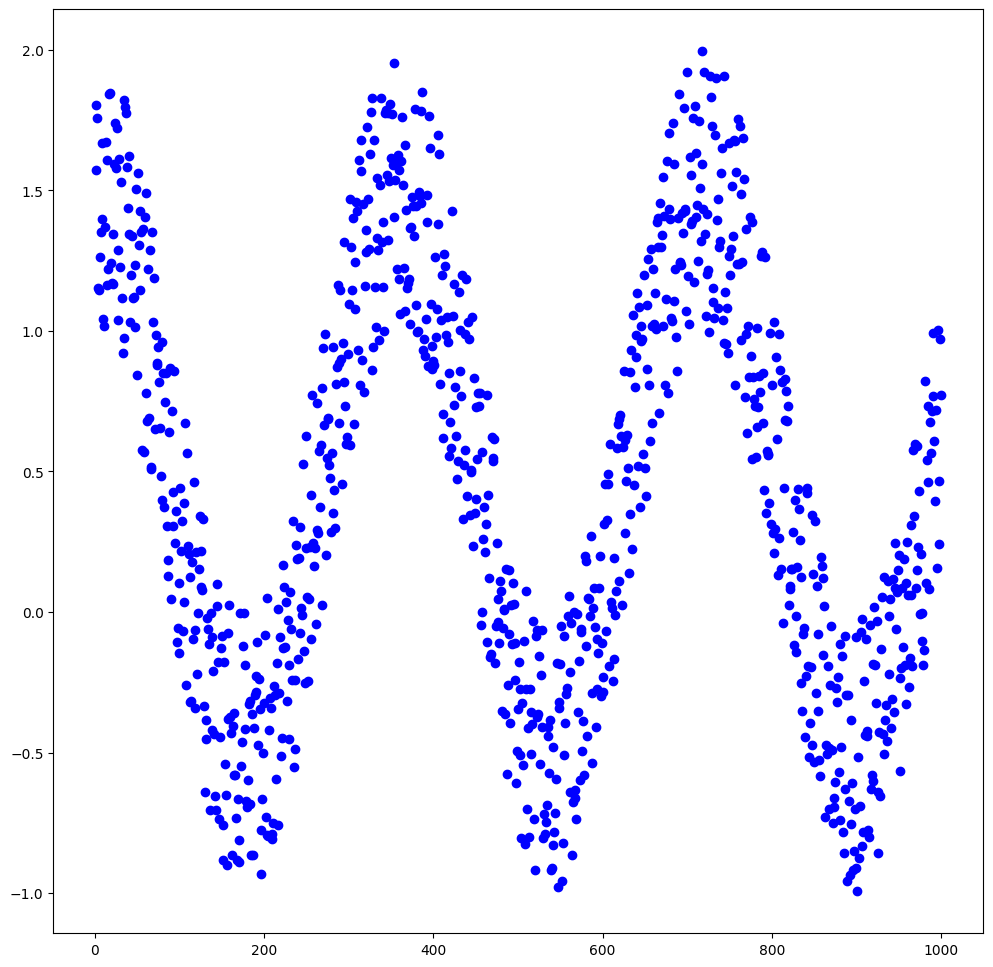

In [23]:
plt.figure(figsize=(12, 12))
plt.scatter(x=x, y=y, color="b")

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [19]:
def cos_function(x, A, B, C, D):
    return A * np.cos(B * x + C) + D

In [24]:
#                a   b         c    d
initial_guess = [1, np.pi/180, 0, 0.5]

In [26]:
popt, pcov = curve_fit(cos_function, x_train, y_train, p0=initial_guess)

In [28]:
popt

array([ 0.99802792,  0.01753101, -0.00995909,  0.48691513])

In [29]:
pcov

array([[ 2.06257576e-04, -1.08083292e-08,  2.02284401e-05,
         1.34352980e-05],
       [-1.08083292e-08,  2.52385488e-09, -1.30449468e-06,
        -1.02273983e-07],
       [ 2.02284401e-05, -1.30449468e-06,  8.82274325e-04,
         6.87259167e-05],
       [ 1.34352980e-05, -1.02273983e-07,  6.87259167e-05,
         1.07996705e-04]])

In [30]:
y_train_pred = cos_function(x_train, *popt)

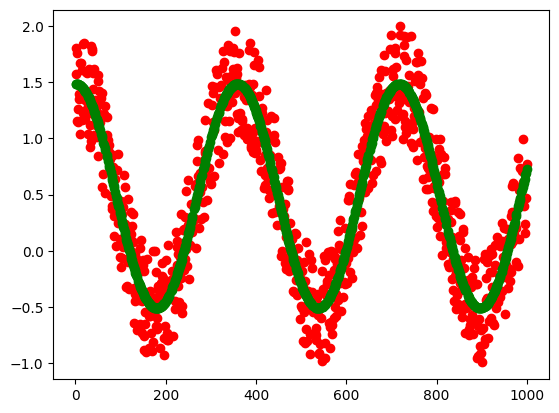

In [34]:
plt.scatter(x=x_train, y=y_train, color="r")
plt.scatter(x=x_train, y=y_train_pred, color="g")

In [36]:
r2_score(y_train, y_train_pred)

0.8591287279952784

In [37]:
y_test_pred = cos_function(x_test, *popt)

In [38]:
r2_score(y_test, y_test_pred)

0.8484741285744583